### MNIST neural network from scratch

#### Fully Connected Layer (Linear Layer)

In [2]:
import numpy as np 

class Linear():
    def __init__(self, in_size, out_size):
        self.W = np.random.randn(in_size, out_size) * 0.01
        self.b = np.zeros((1, out_size))
        self.params = [self.W, self.b]
        self.gradW = None
        self.gradB = None
        self.gradInput = None        

    def forward(self, X):
        self.X = X
        self.output = np.dot(X, self.W) + self.b
        return self.output

    def backward(self, nextgrad):
        self.gradW = np.dot(self.X.T, nextgrad)
        self.gradB = np.sum(nextgrad, axis=0)
        self.gradInput = np.dot(nextgrad, self.W.T)
        return self.gradInput, [self.gradW, self.gradB]

In [3]:
np.random.seed(3)

#### Rectified Linear Activation Layer (ReLU)


In [4]:
class ReLU():
    def __init__(self):
        self.params = []
        self.gradInput = None

    def forward(self, X):
        self.output = np.maximum(X, 0)
        return self.output

    def backward(self, nextgrad):
        self.gradInput = nextgrad.copy()
        self.gradInput[self.output <=0] = 0
        return self.gradInput, []

#### Defining the softmax function

In [5]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    out= exp_x / np.sum(exp_x, axis=1, keepdims=True)
    return out

#### Defining the Cross Entropy Loss

In [6]:
class CrossEntropy:
    def forward(self, X, y):
        self.m = y.shape[0]
        self.p = softmax(X)
        cross_entropy = -np.log(self.p[range(self.m), y])
        loss = cross_entropy[0] / self.m
        return loss
    
    def backward(self, X, y):
        y_idx = y.argmax()        
        grad = softmax(X)
        grad[range(self.m), y] -= 1
        grad /= self.m
        return grad

#### Loading the MNIST dataset

In [7]:
from keras.datasets import mnist # type: ignore
# from keras.utils import np_utils
from tensorflow.keras.utils import to_categorical # type: ignore

In [8]:
(train_features, train_targets), (test_features, test_targets) = mnist.load_data()


train_features = train_features.reshape(60000, 784)
print(train_features.shape)
test_features = test_features.reshape(10000, 784)
print(test_features.shape)


# # normalize inputs from 0-255 to 0-1
train_features = train_features / 255.0
test_features = test_features / 255.0

print(train_targets.shape)
print(test_targets.shape)

X_train = train_features
y_train = train_targets

X_val = test_features
y_val = test_targets


(60000, 784)
(10000, 784)
(60000,)
(10000,)


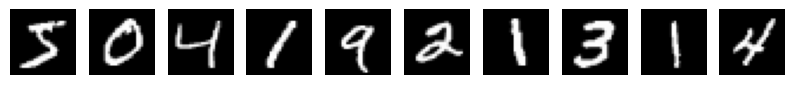

Label for each of the above image: [5 0 4 1 9 2 1 3 1 4]


In [9]:
# visualizing the first 10 images in the dataset and their labels
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.axis('off')
plt.show()
print('Label for each of the above image: %s' % (y_train[0:10]))

#### Here, we define the container NN class that enables the forward prop and backward propagation of the entire network. Note, how this class enables us to add layers of different types and also correctly pass gradients using the chain rule.

In [10]:
class NN():
    def __init__(self, lossfunc=CrossEntropy()):
        self.params = []
        self.layers = []
        self.loss_func = lossfunc
        self.grads = []
        
    def add_layer(self, layer):
        self.layers.append(layer)
        self.params.append(layer.params)

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X
    
    def backward(self, nextgrad):
        self.clear_grad_param()
        for layer in reversed(self.layers):
            nextgrad, grad = layer.backward(nextgrad)
            self.grads.append(grad)
        return self.grads
    
    def train_step(self, X, y):
        out = self.forward(X)
        loss = self.loss_func.forward(out,y)
        nextgrad = self.loss_func.backward(out,y)
        l2 = self.backward(nextgrad)
        return loss, l2
    
    def predict(self, X):
        X = self.forward(X)
        return np.argmax(X, axis=1)
    
    def predict_scores(self, X):
        X = self.forward(X)
        return X
    
    def clear_grad_param(self):
        self.grads = []

#### Defining the update function (SGD with momentum)

In [11]:
def update_params(velocity, params, grads, learning_rate=0.01, mu=0.9):
    for v, p, g, in zip(velocity, params, reversed(grads)):
        for i in range(len(g)):
            v[i] = mu * v[i] + learning_rate * g[i]
            p[i] -= v[i]
            print('Max gradient value:',np.amax(v[i]))
            print('Gradient shape:',v[i].shape)

#### Defining a function which gives us the minibatches (both the datapoint and the corresponding label)

In [12]:
# get minibatches
def minibatch(X, y, minibatch_size):
    n = X.shape[0]
    minibatches = []
    permutation = np.random.permutation(X.shape[0])
    X = X[permutation]
    y = y[permutation]
    
    for i in range(0, n , minibatch_size):
        X_batch = X[i:i + minibatch_size, :]
        y_batch = y[i:i + minibatch_size, ]
        minibatches.append((X_batch, y_batch))
        
    return minibatches

In [13]:
def check_accuracy(y_true, y_pred):
    """
    Computes the accuracy of predictions.

    Parameters:
    y_true (numpy array): True labels
    y_pred (numpy array): Predicted labels

    Returns:
    float: Accuracy percentage
    """
    if len(y_true) == 0:
        return 0.0  # Avoid division by zero
    
    correct_predictions = np.sum(y_true == y_pred)
    accuracy = (correct_predictions / len(y_true)) * 100
    return accuracy

#### The traning loop

In [14]:
def train(net, X_train, y_train, minibatch_size, epoch, learning_rate, mu=0.9, X_val=None, y_val=None):
    val_loss_epoch = []
    minibatches = minibatch(X_train, y_train, minibatch_size)
    minibatches_val = minibatch(X_val, y_val, minibatch_size)

    
    for i in range(epoch):
        loss_batch = []
        val_loss_batch = []
        velocity = []
        for param_layer in net.params:
            p = [np.zeros_like(param) for param in list(param_layer)]
            velocity.append(p)
            
        # iterate over mini batches
        for X_mini, y_mini in minibatches:
            loss, grads = net.train_step(X_mini, y_mini)
            loss_batch.append(loss)
            update_params(velocity, net.params, grads, learning_rate=learning_rate, mu=mu)

        for X_mini_val, y_mini_val in minibatches_val:
            val_loss, _ = net.train_step(X_mini, y_mini)
            val_loss_batch.append(val_loss)
        
        # accuracy of model at end of epoch after all mini batch updates
        m_train = X_train.shape[0]
        m_val = X_val.shape[0]
        y_train_pred = np.array([], dtype="int64")
        y_val_pred = np.array([], dtype="int64")
        y_train1 = []
        y_vall = []
        for i in range(0, m_train, minibatch_size):
            X_tr = X_train[i:i + minibatch_size, : ]
            y_tr = y_train[i:i + minibatch_size,]
            y_train1 = np.append(y_train1, y_tr)
            y_train_pred = np.append(y_train_pred, net.predict(X_tr))

        for i in range(0, m_val, minibatch_size):
            X_va = X_val[i:i + minibatch_size, : ]
            y_va = y_val[i:i + minibatch_size,]
            y_vall = np.append(y_vall, y_va)
            y_val_pred = np.append(y_val_pred, net.predict(X_va))
            
        train_acc = check_accuracy(y_train1, y_train_pred)
        val_acc = check_accuracy(y_vall, y_val_pred)

        mean_train_loss = sum(loss_batch) / float(len(loss_batch))
        mean_val_loss = sum(val_loss_batch) / float(len(val_loss_batch))
        
        val_loss_epoch.append(mean_val_loss)
        print("Loss = {0} | Training Accuracy = {1} | Val Loss = {2} | Val Accuracy = {3}".format(mean_train_loss, train_acc, mean_val_loss, val_acc))
    return net

#### Checking the accuracy of the model 

In [15]:
def check_accuracy(y_true, y_pred):
    return np.mean(y_pred == y_true)

#### Invoking all that we have created until now

In [16]:
from random import shuffle

## input size
input_dim = X_train.shape[1]

## hyperparameters
iterations = 10
learning_rate = 0.1
hidden_nodes = 32
output_nodes = 10

## define neural net
nn = NN()
nn.add_layer(Linear(input_dim, hidden_nodes))
nn.add_layer(ReLU())
nn.add_layer(Linear(hidden_nodes, output_nodes))

nn = train(nn, X_train , y_train, minibatch_size=200, epoch=10, \
           learning_rate=learning_rate, X_val=X_val, y_val=y_val)

Max gradient value: 0.00018433421102658702
Gradient shape: (784, 32)
Max gradient value: 0.00010350486512577992
Gradient shape: (1, 32)
Max gradient value: 0.0005541594115222734
Gradient shape: (32, 10)
Max gradient value: 0.002984907075109512
Gradient shape: (1, 10)
Max gradient value: 0.000396496464810916
Gradient shape: (784, 32)
Max gradient value: 0.00015227791559624306
Gradient shape: (1, 32)
Max gradient value: 0.0010480784559195274
Gradient shape: (32, 10)
Max gradient value: 0.005639820673001145
Gradient shape: (1, 10)
Max gradient value: 0.00045458788020786027
Gradient shape: (784, 32)
Max gradient value: 0.0002590588288155834
Gradient shape: (1, 32)
Max gradient value: 0.0015705204373283395
Gradient shape: (32, 10)
Max gradient value: 0.0019701621684181875
Gradient shape: (1, 10)
Max gradient value: 0.0005985385245739707
Gradient shape: (784, 32)
Max gradient value: 0.0003260813229759256
Gradient shape: (1, 32)
Max gradient value: 0.0017861548971908237
Gradient shape: (32, 1

#### for a single image and showing its prediction

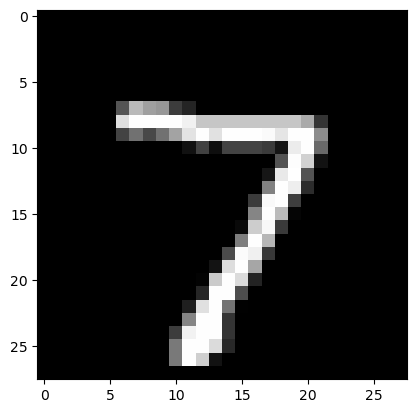

In [17]:
plt.imshow(X_val[0].reshape(28,28), cmap='gray')
plt.show()

In [18]:
# Predict Scores for each class
prediction = nn.predict_scores(X_val[0:])
prediction

array([[ -1.91651193,  -5.74711716,  -1.33109031, ...,  17.33751905,
         -1.06333759,   2.02192688],
       [ -7.27440012,   3.64930078,  15.19134686, ...,  -2.37964324,
          4.51063458,  -7.28743373],
       [ -7.62622415,  10.80140791,   3.00225581, ...,   4.27476371,
          1.05431376,  -4.75004955],
       ...,
       [ -6.31469754, -15.76996629,  -5.70113899, ...,   8.04543185,
          2.91946368,   6.3964007 ],
       [ -2.41060813,  -7.43502305,  -3.56487388, ...,   0.90899566,
          7.6138025 ,  -3.9352488 ],
       [ -3.11554744,  -5.24372198,   8.50019974, ..., -12.20539474,
         -2.23522606,  -8.96724861]])

In [19]:
print ("Scores")
print (prediction)

Scores
[[ -1.91651193  -5.74711716  -1.33109031 ...  17.33751905  -1.06333759
    2.02192688]
 [ -7.27440012   3.64930078  15.19134686 ...  -2.37964324   4.51063458
   -7.28743373]
 [ -7.62622415  10.80140791   3.00225581 ...   4.27476371   1.05431376
   -4.75004955]
 ...
 [ -6.31469754 -15.76996629  -5.70113899 ...   8.04543185   2.91946368
    6.3964007 ]
 [ -2.41060813  -7.43502305  -3.56487388 ...   0.90899566   7.6138025
   -3.9352488 ]
 [ -3.11554744  -5.24372198   8.50019974 ... -12.20539474  -2.23522606
   -8.96724861]]


In [20]:
np.argmax(prediction)

63842

In [21]:
predict_class = nn.predict(X_val[0:])
predict_class

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [26]:
n= len(predict_class)
n= int(n/100)

In [27]:
fig, axes = plt.subplots(1, n, figsize=(12, 4))  # Create a 1-row, 6-column subplot

for i in range(n):
    axes[i].imshow(X_val[i].reshape(28, 28), cmap='Blues')
    axes[i].axis('off')  # Hide axes for better visualization

plt.show()

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

In [28]:
# Original class
y_val[0:]

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [ ]:
# Define input size
input_dim = X_train.shape[1]

# Set hyperparameters
learning_rate = 0.1
hidden_nodes = 32
output_nodes = 10

# Initialize neural network
nn = NN()
nn.add_layer(Linear(input_dim, hidden_nodes))
nn.add_layer(ReLU())
nn.add_layer(Linear(hidden_nodes, output_nodes))

# Train the model
nn = train(nn, X_train, y_train, minibatch_size=200, epoch=10, 
           learning_rate=learning_rate, X_val=X_val, y_val=y_val)


Max gradient value: 0.0002352445872917025
Gradient shape: (784, 32)
Max gradient value: 0.00013118630249810733
Gradient shape: (1, 32)
Max gradient value: 0.0006292337995954582
Gradient shape: (32, 10)
Max gradient value: 0.0039720992076548575
Gradient shape: (1, 10)
Max gradient value: 0.00032261300969838643
Gradient shape: (784, 32)
Max gradient value: 0.0002486044600356949
Gradient shape: (1, 32)
Max gradient value: 0.0013330805591953644
Gradient shape: (32, 10)
Max gradient value: 0.003757500584092699
Gradient shape: (1, 10)
Max gradient value: 0.0004187208395314266
Gradient shape: (784, 32)
Max gradient value: 0.0002845355918833678
Gradient shape: (1, 32)
Max gradient value: 0.001791871065373176
Gradient shape: (32, 10)
Max gradient value: 0.0045956305740151695
Gradient shape: (1, 10)
Max gradient value: 0.0004898993822575262
Gradient shape: (784, 32)
Max gradient value: 0.00032093011836945197
Gradient shape: (1, 32)
Max gradient value: 0.0019230008198321347
Gradient shape: (32, 1

In [29]:
nn.predict(X_val[0:])
y_val[0:]

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [37]:
y_val[0]

7

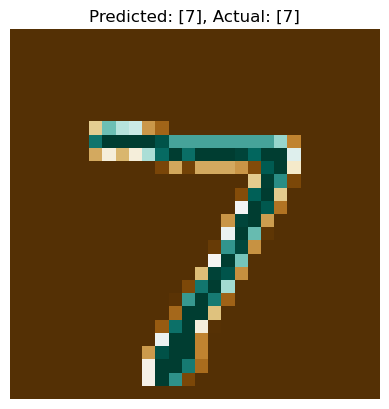

In [33]:
predicted_label = nn.predict(X_val[:1])

# Get the actual label
actual_label = y_val[:1]

# Reshape X_val[107] if needed (assuming it's a 28x28 image)
image = X_val[:1].reshape(28, 28)

# Plot the image
plt.imshow(image, cmap='BrBG')
plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
plt.axis('off')  # Hide axes
plt.show()